In [1]:
# =============================================================
# Detecção de enchentes em imagens - Transfer Learning
# Modelo escolhido: MobileNetV2 (diferente do mostrado em aula, que usava Xception)
# Execução: local (Windows / CPU). Dataset: Louisiana Flood 2016 (Kaggle).
# =============================================================
import os
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

import kagglehub

print("Keras:", keras.__version__)


Keras: 3.14.0


In [2]:
# Baixa (e faz cache) do dataset via kagglehub.
# Em vez de copiar para /content (Colab), usamos direto a pasta de cache local.
data_dir = kagglehub.dataset_download("rahultp97/louisiana-flood-2016")
print("Dataset disponível em:", data_dir)

# Estrutura esperada: data_dir/{train.csv, test.csv, train/, test/}
print("Conteúdo:", os.listdir(data_dir))


Dataset disponível em: C:\Users\tcpas\.cache\kagglehub\datasets\rahultp97\louisiana-flood-2016\versions\4
Conteúdo: ['test', 'test.csv', 'train', 'train.csv']


In [3]:
# Os CSVs têm as colunas: 'Image ID', 'Normal', 'Flooded'.
# Para a classificação BINÁRIA usamos a coluna 'Flooded' como alvo:
#   1 = imagem com enchente | 0 = sem enchente (inclui "normal" e imagens irrelevantes).
train_df = pd.read_csv(os.path.join(data_dir, "train.csv"))
test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))

print("Treino:", len(train_df), "| Teste:", len(test_df))
print("\nDistribuição de classes (treino):")
print(train_df["Flooded"].value_counts())
print("\nDistribuição de classes (teste):")
print(test_df["Flooded"].value_counts())


Treino: 270 | Teste: 52

Distribuição de classes (treino):
Flooded
0    184
1     86
Name: count, dtype: int64

Distribuição de classes (teste):
Flooded
0    36
1    16
Name: count, dtype: int64


In [4]:
import tensorflow as tf

# MobileNetV2 foi pré-treinado em 224x224. As imagens são entregues ao modelo
# em float no intervalo [0, 255]; a normalização específica do MobileNetV2
# ([-1, 1]) é feita por uma camada DENTRO do modelo (ver célula seguinte),
# o que deixa o .keras salvo autossuficiente para o agente de inferência.
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def _load_image_py(path_tensor, label):
    path = path_tensor.numpy().decode("utf-8")
    try:
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMAGE_SIZE)
        img = tf.cast(img, tf.float32)  # mantém em [0, 255]
        return img, label
    except Exception as e:
        print(f"Erro ao processar {path}: {e}")
        return tf.zeros((*IMAGE_SIZE, 3), dtype=tf.float32), label


def load_image(path, label):
    img, lbl = tf.py_function(
        _load_image_py, inp=[path, label], Tout=[tf.float32, tf.float32]
    )
    img.set_shape([*IMAGE_SIZE, 3])
    lbl.set_shape([])
    return img, lbl


def make_dataset(df, subset, training):
    paths = [os.path.join(data_dir, subset, f) for f in df["Image ID"].values]
    labels = df["Flooded"].values.astype("float32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(buffer_size=len(paths))
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)


print("Criando datasets...")
train_dataset = make_dataset(train_df, "train", training=True)
test_dataset = make_dataset(test_df, "test", training=False)

# Verificação de um batch
for images, labels in train_dataset.take(1):
    print("Batch de imagens:", images.shape, images.dtype,
          "| min/max:", float(tf.reduce_min(images)), float(tf.reduce_max(images)))
    print("Batch de labels:", labels.shape, labels.dtype)


Criando datasets...


Batch de imagens: (32, 224, 224, 3) <dtype: 'float32'> | min/max: 0.0 255.0
Batch de labels: (32,) <dtype: 'float32'>


In [5]:
from keras import layers
from keras.applications import MobileNetV2
from keras.models import Model
from keras.optimizers import Adam

# --- Modelo base: MobileNetV2 pré-treinado na ImageNet, sem o topo ---
base_model = MobileNetV2(
    include_top=False,
    weights="imagenet",
    input_shape=(*IMAGE_SIZE, 3),
)
# Congela a base: usamos como extrator de features (transfer learning).
base_model.trainable = False

# --- Cabeça de classificação binária ---
inputs = layers.Input(shape=(*IMAGE_SIZE, 3), name="entrada_rgb_0_255")

# Augmentation: ativa só no treino (training=True), ajuda no dataset pequeno (270 imgs).
x = layers.RandomFlip("horizontal")(inputs)
x = layers.RandomRotation(0.1)(x)
x = layers.RandomZoom(0.1)(x)

# Normalização do MobileNetV2: [0,255] -> [-1,1]. Fica embutida no modelo,
# então na inferência basta passar a imagem redimensionada em [0,255].
x = layers.Rescaling(1.0 / 127.5, offset=-1.0, name="preprocess_mobilenetv2")(x)

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
output_layer = layers.Dense(1, activation="sigmoid", name="enchente")(x)

model = Model(inputs=inputs, outputs=output_layer)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model.summary()
print("\nModelo MobileNetV2 (transfer learning) criado e compilado com sucesso!")


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ entrada_rgb_0_255 (InputLayer)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ preprocess_mobilenetv2          │ (None, 224, 224, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enchente (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


Modelo MobileNetV2 (transfer learning) criado e compilado com sucesso!


In [6]:
from sklearn.utils.class_weight import compute_class_weight

MODEL_PATH = "flood_mobilenetv2.keras"

# Pesos de classe: o dataset é desbalanceado (mais imagens "sem enchente").
y_train = train_df["Flooded"].values
class_weights = compute_class_weight("balanced", classes=np.array([0, 1]), y=y_train)
class_weight = {0: class_weights[0], 1: class_weights[1]}
print("class_weight:", class_weight)

callbacks = [
    ModelCheckpoint(MODEL_PATH, monitor="val_loss", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True, verbose=1),
]

# Mede o tempo total de treinamento (requisito da entrega).
start = time.time()
hist = model.fit(
    train_dataset,
    epochs=60,
    validation_data=test_dataset,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=2,
)
train_time = time.time() - start
print(f"\nTempo total de treinamento: {train_time:.1f} s "
      f"({len(hist.history['loss'])} épocas executadas)")


class_weight: {0: np.float64(0.7336956521739131), 1: np.float64(1.569767441860465)}
Epoch 1/60



Epoch 1: val_loss improved from None to 1.18936, saving model to flood_mobilenetv2.keras



Epoch 1: finished saving model to flood_mobilenetv2.keras


9/9 - 4s - 499ms/step - accuracy: 0.3630 - loss: 0.9891 - val_accuracy: 0.3077 - val_loss: 1.1894


Epoch 2/60


...


Epoch 60: val_loss improved from 0.38958 to 0.38497, saving model to flood_mobilenetv2.keras



Epoch 60: finished saving model to flood_mobilenetv2.keras


9/9 - 2s - 242ms/step - accuracy: 0.9111 - loss: 0.2390 - val_accuracy: 0.8462 - val_loss: 0.3850


Restoring model weights from the end of the best epoch: 60.



Tempo total de treinamento: 123.2 s (60 épocas executadas)


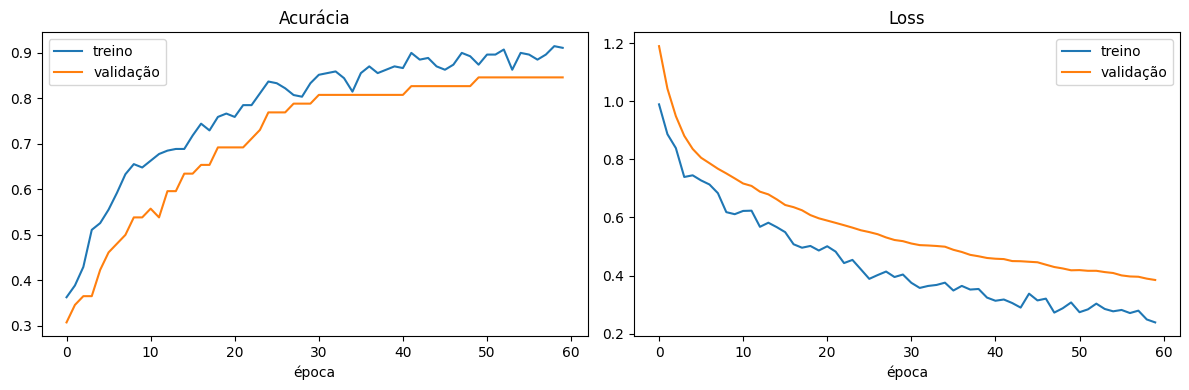

In [7]:
# --- Curvas de treinamento (acurácia e loss) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist.history["accuracy"], label="treino")
axes[0].plot(hist.history["val_accuracy"], label="validação")
axes[0].set_title("Acurácia"); axes[0].set_xlabel("época"); axes[0].legend()
axes[1].plot(hist.history["loss"], label="treino")
axes[1].plot(hist.history["val_loss"], label="validação")
axes[1].set_title("Loss"); axes[1].set_xlabel("época"); axes[1].legend()
plt.tight_layout()
plt.show()


Acurácia no teste: 0.8462

Relatório de classificação:
                  precision    recall  f1-score   support

sem enchente (0)       0.94      0.83      0.88        36
    enchente (1)       0.70      0.88      0.78        16

        accuracy                           0.85        52
       macro avg       0.82      0.85      0.83        52
    weighted avg       0.86      0.85      0.85        52



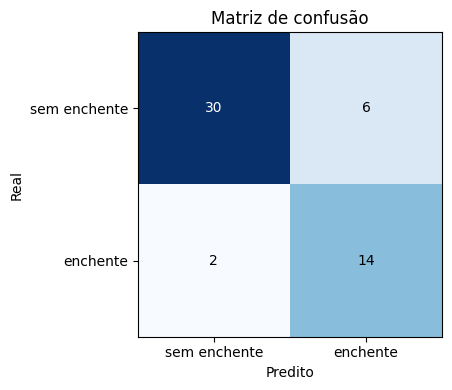

In [8]:
# =============================================================
# AVALIAÇÃO NO CONJUNTO DE TESTE
# Requisitos da entrega: acurácia, tempo de processamento e métricas.
# =============================================================
# Recarrega o melhor modelo salvo pelo checkpoint (menor val_loss).
best_model = keras.models.load_model(MODEL_PATH)

# Probabilidades preditas para o conjunto de teste.
y_true = test_df["Flooded"].values.astype(int)
y_prob = best_model.predict(test_dataset, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

acc = accuracy_score(y_true, y_pred)
print(f"Acurácia no teste: {acc:.4f}\n")
print("Relatório de classificação:")
print(classification_report(y_true, y_pred,
                            target_names=["sem enchente (0)", "enchente (1)"]))

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["sem enchente", "enchente"])
ax.set_yticklabels(["sem enchente", "enchente"])
ax.set_xlabel("Predito"); ax.set_ylabel("Real"); ax.set_title("Matriz de confusão")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.tight_layout()
plt.show()


In [9]:
# =============================================================
# TEMPO DE INFERÊNCIA (latência por imagem)
# Simula o uso real do agente: classificar UMA imagem por vez a partir de arquivo.
# =============================================================
def carregar_para_inferencia(caminho):
    """Lê uma imagem de arquivo e devolve o tensor (1, 224, 224, 3) em [0,255]."""
    img = tf.io.read_file(caminho)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.float32)
    return tf.expand_dims(img, 0)


test_paths = [os.path.join(data_dir, "test", f) for f in test_df["Image ID"].values]

# Warm-up (primeira chamada inclui custo de tracing/compilação do grafo).
_ = best_model.predict(carregar_para_inferencia(test_paths[0]), verbose=0)

tempos = []
for caminho in test_paths:
    x = carregar_para_inferencia(caminho)
    t0 = time.time()
    _ = best_model.predict(x, verbose=0)
    tempos.append((time.time() - t0) * 1000)  # ms

tempos = np.array(tempos)
print(f"Imagens avaliadas: {len(tempos)}")
print(f"Latência por imagem -> média: {tempos.mean():.1f} ms | "
      f"mediana: {np.median(tempos):.1f} ms | "
      f"mín: {tempos.min():.1f} ms | máx: {tempos.max():.1f} ms")
print(f"Throughput aproximado: {1000 / tempos.mean():.1f} imagens/segundo")


Imagens avaliadas: 52
Latência por imagem -> média: 39.4 ms | mediana: 39.0 ms | mín: 35.0 ms | máx: 51.0 ms
Throughput aproximado: 25.4 imagens/segundo


In [10]:
# =============================================================
# RESUMO DOS RESULTADOS  (MobileNetV2  vs.  Xception de aula)
# =============================================================
# Referência (Xception, notebook base, mesmo dataset): val_accuracy ~0.94, val_loss ~0.17,
# ~22M parâmetros, épocas de ~70-100s na 1ª passada (modelo bem mais pesado).
print("=" * 56)
print(" RESULTADOS - MobileNetV2 (transfer learning)")
print("=" * 56)
print(f" Parâmetros totais ....... {best_model.count_params():,}")
print(f" Épocas executadas ....... {len(hist.history['loss'])}")
print(f" Tempo de treinamento .... {train_time:.1f} s")
print(f" Acurácia (teste) ........ {acc:.4f}")
print(f" Latência média/imagem ... {tempos.mean():.1f} ms")
print(f" Modelo salvo em ......... {os.path.abspath(MODEL_PATH)}")
print("=" * 56)
print("\nO arquivo .keras é autossuficiente (augmentation + normalização embutidas)")
print("e será carregado pelo agente de monitoramento (Parte 2).")


 RESULTADOS - MobileNetV2 (transfer learning)
 Parâmetros totais ....... 2,259,265
 Épocas executadas ....... 60
 Tempo de treinamento .... 123.2 s
 Acurácia (teste) ........ 0.8462
 Latência média/imagem ... 39.4 ms
 Modelo salvo em ......... C:\dev\agentes-enchente\flood_mobilenetv2.keras

O arquivo .keras é autossuficiente (augmentation + normalização embutidas)
e será carregado pelo agente de monitoramento (Parte 2).
